# JRN FK-Shuffling Confound Control on rel-f1

**Tests whether JRN (Join Reproduction Number) captures genuine relational join structure or merely reflects child-table feature quality.**

For each FK join × task combination in the rel-f1 dataset:
1. Compute **normal JRN** via LightGBM probes
2. Compute **shuffled JRN** (FK column permuted to break true parent-child associations)
3. Decompose JRN into **structural component** (destroyed by shuffling) and **feature component** (survives shuffling)
4. Run **statistical tests** to assess whether the structural component is significant

This notebook loads pre-computed experiment results (13 FK joins × 3 driver tasks) and demonstrates the analysis pipeline.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# tabulate — NOT on Colab by default, always install
_pip('tabulate==0.9.0')

# Core packages: pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')
    _pip('scipy==1.15.3')  # 1.16.3 needs Python>=3.11; 1.15.3 is closest for 3.10


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import math
import os
from collections import defaultdict
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from tabulate import tabulate

## Data Loading

Load the pre-computed JRN FK-Shuffling experiment results. The data contains per-join JRN decompositions for 13 FK joins across 3 driver prediction tasks (DNF, Top-3, Position).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-bc07ab-join-reproduction-number-epidemiology-in/main/experiment_iter4_jrn_fk_shufflin/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded experiment: {data['metadata']['title']}")
print(f"  Dataset: {data['metadata']['dataset']}")
print(f"  Model: {data['metadata']['model']}")
print(f"  FK Joins: {data['metadata']['n_joins']}, Tasks: {data['metadata']['n_tasks']}")
print(f"  Seeds: {data['metadata']['n_seeds']}, Shuffles: {data['metadata']['n_shuffles']}")

Loaded experiment: JRN FK-Shuffling Confound Control on rel-f1
  Dataset: rel-f1
  Model: LightGBM
  FK Joins: 13, Tasks: 3
  Seeds: 3, Shuffles: 5


## Configuration

Define experiment parameters and task definitions matching the original experiment.

In [5]:
# ── Experiment parameters (from original experiment) ──
SEEDS = [42, 123, 777]
N_SHUFFLES = 5  # original: 5 FK-shuffles per join

TASKS = ["rel-f1/driver-dnf", "rel-f1/driver-top3", "rel-f1/driver-position"]
TASK_TYPES = {
    "rel-f1/driver-dnf": "binary_classification",
    "rel-f1/driver-top3": "binary_classification",
    "rel-f1/driver-position": "regression",
}

LGB_PARAMS_BASE = {
    "n_estimators": 200,  # original: 200
    "max_depth": 6,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_child_samples": 10,
    "verbose": -1,
    "n_jobs": 1,
}

# Significance threshold
ALPHA = 0.05

## Extract Per-Join Results

Parse the pre-computed results to extract normal and shuffled JRN values for each (join, task) pair, then decompose into structural and feature components.

In [6]:
# ── Extract per-join results from loaded data ──
results = data["results"]
per_join_results = results["per_join_results"]
summary_stats = results["summary_statistics"]

print(f"Number of FK joins analyzed: {len(per_join_results)}")
print(f"Number of valid (join, task) pairs: {summary_stats['n_valid_pairs']}")
print()

# Build decomposition dict from per_join_results (mirrors original script's decomposition)
decomposition = {}
for pjr in per_join_results:
    ji = pjr["join_idx"]
    for short_task, task_data_entry in pjr["per_task"].items():
        task_name = f"rel-f1/driver-{short_task}"
        decomposition[(ji, task_name)] = {
            "normal_jrn": task_data_entry["normal_jrn"],
            "shuffled_jrn_mean": task_data_entry["shuffled_jrn"],
            "jrn_structural": task_data_entry["jrn_structural"],
            "jrn_feature": task_data_entry["jrn_feature"],
            "structural_fraction": task_data_entry["structural_fraction"],
        }

print(f"Decomposition entries: {len(decomposition)}")
for key in sorted(decomposition.keys())[:6]:
    d = decomposition[key]
    print(f"  Join #{key[0]}, {key[1].split('/')[-1]}: "
          f"normal={d['normal_jrn']:.4f}, shuffled={d['shuffled_jrn_mean']:.4f}, "
          f"structural={d['jrn_structural']:.4f}, feature={d['jrn_feature']:.4f}")
print("  ...")

Number of FK joins analyzed: 13
Number of valid (join, task) pairs: 39

Decomposition entries: 39
  Join #0, driver-driver-dnf: normal=1.2753, shuffled=1.2549, structural=0.0204, feature=0.2549
  Join #0, driver-driver-position: normal=1.1345, shuffled=1.1702, structural=-0.0357, feature=0.1702
  Join #0, driver-driver-top3: normal=1.3342, shuffled=1.2813, structural=0.0529, feature=0.2813
  Join #1, driver-driver-dnf: normal=1.0000, shuffled=1.0000, structural=0.0000, feature=0.0000
  Join #1, driver-driver-position: normal=0.9323, shuffled=0.9321, structural=0.0002, feature=-0.0679
  Join #1, driver-driver-top3: normal=1.0000, shuffled=1.0000, structural=0.0000, feature=0.0000
  ...


## Statistical Tests: Paired t-test and Wilcoxon

Test whether normal JRN is significantly higher than shuffled JRN across all (join, task) pairs. This is the core test: if the structural component (normal - shuffled) is statistically significant, JRN captures genuine relational structure.

In [7]:
# ── Statistical tests (from original script STEP 7) ──
normal_jrns_list = []
shuffled_jrns_list = []
for key in sorted(decomposition.keys()):
    normal_jrns_list.append(decomposition[key]["normal_jrn"])
    shuffled_jrns_list.append(decomposition[key]["shuffled_jrn_mean"])

normal_arr = np.array(normal_jrns_list)
shuffled_arr = np.array(shuffled_jrns_list)

if len(normal_arr) >= 3:
    t_stat, p_ttest = stats.ttest_rel(normal_arr, shuffled_arr)
    try:
        w_stat, p_wilcoxon = stats.wilcoxon(normal_arr - shuffled_arr)
    except ValueError:
        w_stat, p_wilcoxon = float("nan"), float("nan")

    diffs = normal_arr - shuffled_arr
    cohens_d = float(np.mean(diffs) / (np.std(diffs, ddof=1) + 1e-8))
else:
    t_stat = p_ttest = w_stat = p_wilcoxon = cohens_d = float("nan")

structural_dominant_fraction = (
    sum(1 for d in decomposition.values() if d["structural_fraction"] > 0.5)
    / max(len(decomposition), 1)
)

print("=" * 60)
print("STATISTICAL TESTS: Normal JRN vs Shuffled JRN")
print("=" * 60)
print(f"  Number of (join, task) pairs:  {len(normal_arr)}")
print(f"  Mean normal JRN:               {np.mean(normal_arr):.4f}")
print(f"  Mean shuffled JRN:             {np.mean(shuffled_arr):.4f}")
print(f"  Mean structural JRN:           {np.mean(diffs):.4f}")
print(f"  Mean feature JRN:              {np.mean(shuffled_arr - 1.0):.4f}")
print()
print(f"  Paired t-test:  t={t_stat:.4f}, p={p_ttest:.6f}")
print(f"  Wilcoxon test:  W={w_stat:.1f}, p={p_wilcoxon:.6f}")
print(f"  Cohen's d:      {cohens_d:.4f}")
print(f"  Structural dominant fraction:  {structural_dominant_fraction:.4f}")
print()
if not math.isnan(p_ttest) and p_ttest < ALPHA:
    print(f"  ✓ Structural component is STATISTICALLY SIGNIFICANT (p < {ALPHA})")
else:
    print(f"  ✗ Structural component is NOT significant (p >= {ALPHA})")

STATISTICAL TESTS: Normal JRN vs Shuffled JRN
  Number of (join, task) pairs:  39
  Mean normal JRN:               1.1494
  Mean shuffled JRN:             1.1033
  Mean structural JRN:           0.0461
  Mean feature JRN:              0.1033

  Paired t-test:  t=4.3186, p=0.000109
  Wilcoxon test:  W=7.0, p=0.000068
  Cohen's d:      0.6915
  Structural dominant fraction:  0.0513

  ✓ Structural component is STATISTICALLY SIGNIFICANT (p < 0.05)


## Correlation Analysis: Structural JRN vs Fanout Statistics

Compute Spearman rank correlations between per-join average structural JRN and join characteristics (fanout mean, fanout max). This reveals whether certain join shapes amplify the structural signal.

In [8]:
# ── Correlation analysis (from original script STEP 8) ──
per_join_structural = defaultdict(list)
for (ji, task_name), dec in decomposition.items():
    per_join_structural[ji].append(dec["jrn_structural"])

avg_structural_jrns = []
fanout_means = []
fanout_maxes = []
join_labels = []

for pjr in per_join_results:
    ji = pjr["join_idx"]
    if ji in per_join_structural:
        avg_s = float(np.mean(per_join_structural[ji]))
        avg_structural_jrns.append(avg_s)
        fanout_means.append(pjr.get("fanout_mean", 0))
        fanout_maxes.append(pjr.get("fanout_max", 0))
        join_labels.append(f"#{ji}: {pjr['source_table']}->{pjr['target_table']}")

correlation_analysis = {}
if len(avg_structural_jrns) >= 3:
    for label, vals in [
        ("structural_vs_fanout_mean", fanout_means),
        ("structural_vs_fanout_max", fanout_maxes),
    ]:
        try:
            rho, p = stats.spearmanr(avg_structural_jrns, vals)
            correlation_analysis[label] = {"rho": float(rho), "p": float(p)}
        except Exception:
            correlation_analysis[label] = {"rho": float("nan"), "p": float("nan")}

print("Spearman Correlations (structural JRN vs join characteristics):")
for label, vals in correlation_analysis.items():
    sig = "✓ sig" if vals["p"] < ALPHA else "✗ n.s."
    print(f"  {label}: rho={vals['rho']:.4f}, p={vals['p']:.4f} [{sig}]")

Spearman Correlations (structural JRN vs join characteristics):
  structural_vs_fanout_mean: rho=-0.1337, p=0.6632 [✗ n.s.]
  structural_vs_fanout_max: rho=-0.1226, p=0.6899 [✗ n.s.]


## Per-Join Domain Interpretation

Generate domain-specific interpretations for each join's decomposition, classifying structural signal strength as HIGH, MODERATE, LOW, or NEGATIVE.

In [9]:
# ── Per-join interpretation (from original script _interpret_join) ──
domain_notes = {
    ("results", "drivers"): "Race results are highly driver-specific; position/points directly tied to individual driver performance.",
    ("standings", "drivers"): "Championship standings are driver-specific accumulations; strong structural signal expected.",
    ("qualifying", "drivers"): "Qualifying positions directly reflect individual driver pace.",
    ("results", "races"): "Race features (circuit, weather) affect all drivers equally; moderate structural signal.",
    ("standings", "races"): "Race context for standings provides temporal signal about championship progression.",
    ("qualifying", "races"): "Race context for qualifying provides circuit-specific qualifying patterns.",
    ("qualifying", "constructors"): "Constructor affects qualifying through car performance; moderate structural signal.",
    ("results", "constructors"): "Constructor affects results through car competitiveness; structural but shared across team drivers.",
    ("races", "circuits"): "Circuit characteristics affect race outcomes; indirect driver connection via bridge table.",
    ("constructor_standings", "races"): "Constructor standings by race; indirect connection to drivers.",
    ("constructor_standings", "constructors"): "Constructor standings for constructor; indirect driver connection.",
    ("constructor_results", "races"): "Constructor race results; indirect driver connection.",
    ("constructor_results", "constructors"): "Constructor-level results; indirect driver connection.",
}

# Print per-join summary table
table_rows = []
for pjr in per_join_results:
    avg_s = pjr.get("avg_structural")
    avg_f = pjr.get("avg_feature")
    avg_n = pjr.get("avg_normal_jrn")
    if avg_s is not None:
        if avg_s > 0.05: level = "HIGH"
        elif avg_s > 0.01: level = "MODERATE"
        elif avg_s > -0.01: level = "LOW"
        else: level = "NEGATIVE"
    else:
        level = "N/A"
    table_rows.append([
        f"#{pjr['join_idx']}",
        f"{pjr['source_table']}->{pjr['target_table']}",
        f"{avg_n:.4f}" if avg_n is not None else "N/A",
        f"{avg_s:.4f}" if avg_s is not None else "N/A",
        f"{avg_f:.4f}" if avg_f is not None else "N/A",
        level,
    ])

print(tabulate(table_rows, 
    headers=["Join", "Tables", "Normal JRN", "Structural", "Feature", "Level"],
    tablefmt="grid"))

+--------+-------------------------------------+--------------+--------------+-----------+----------+
| Join   | Tables                              |   Normal JRN |   Structural |   Feature | Level    |
+========+=====================================+==============+==============+===========+==========+
| #0     | races->circuits                     |       1.248  |       0.0125 |    0.2355 | MODERATE |
+--------+-------------------------------------+--------------+--------------+-----------+----------+
| #1     | constructor_standings->races        |       0.9774 |       0.0001 |   -0.0226 | LOW      |
+--------+-------------------------------------+--------------+--------------+-----------+----------+
| #2     | constructor_standings->constructors |       0.9817 |       0      |   -0.0183 | LOW      |
+--------+-------------------------------------+--------------+--------------+-----------+----------+
| #3     | standings->races                    |       1.2454 |       0.0531 |    

## Conclusion

Generate the experiment conclusion based on statistical test results, mirroring the original script's logic.

In [10]:
# ── Conclusion logic (from original script STEP 10) ──
mean_struct = float(np.mean(normal_arr - shuffled_arr))
mean_feat = float(np.mean(shuffled_arr - 1.0))

if not math.isnan(p_ttest) and p_ttest < ALPHA:
    if structural_dominant_fraction > 0.5:
        conclusion = (
            f"Structural component DOMINATES JRN signal (paired t-test p={p_ttest:.6f}, "
            f"Cohen's d={cohens_d:.2f}, structural dominant in {structural_dominant_fraction*100:.0f}% of pairs). "
            f"Normal JRN is significantly higher than shuffled JRN, confirming that JRN captures "
            f"genuine relational join structure beyond child-table feature quality. "
            f"Mean structural JRN={mean_struct:.4f}, mean feature JRN={mean_feat:.4f}."
        )
    else:
        conclusion = (
            f"Structural component is STATISTICALLY SIGNIFICANT but feature component is larger in magnitude "
            f"(paired t-test p={p_ttest:.6f}, Cohen's d={cohens_d:.2f}, structural dominant in only "
            f"{structural_dominant_fraction*100:.0f}% of pairs). Normal JRN is reliably higher than shuffled JRN "
            f"(mean structural={mean_struct:.4f}), confirming genuine structural signal exists. However, "
            f"the feature component (mean={mean_feat:.4f}) is larger for most joins. JRN captures BOTH "
            f"structural and feature components, with the structural component being a significant but "
            f"secondary contributor."
        )
elif not math.isnan(p_ttest):
    conclusion = (
        f"Structural component does NOT significantly differ from zero (paired t-test p={p_ttest:.4f}). "
        f"JRN may primarily reflect feature quality rather than join structure. "
        f"Mean structural={mean_struct:.4f}, mean feature={mean_feat:.4f}."
    )
else:
    conclusion = "Insufficient data for statistical tests."

print("CONCLUSION:")
print("=" * 60)
print(conclusion)

CONCLUSION:
Structural component is STATISTICALLY SIGNIFICANT but feature component is larger in magnitude (paired t-test p=0.000109, Cohen's d=0.69, structural dominant in only 5% of pairs). Normal JRN is reliably higher than shuffled JRN (mean structural=0.0461), confirming genuine structural signal exists. However, the feature component (mean=0.1033) is larger for most joins. JRN captures BOTH structural and feature components, with the structural component being a significant but secondary contributor.


## Visualization

### 1. JRN Decomposition: Structural vs Feature components per join
### 2. Normal vs Shuffled JRN heatmaps across joins and tasks
### 3. Per-task structural JRN distribution

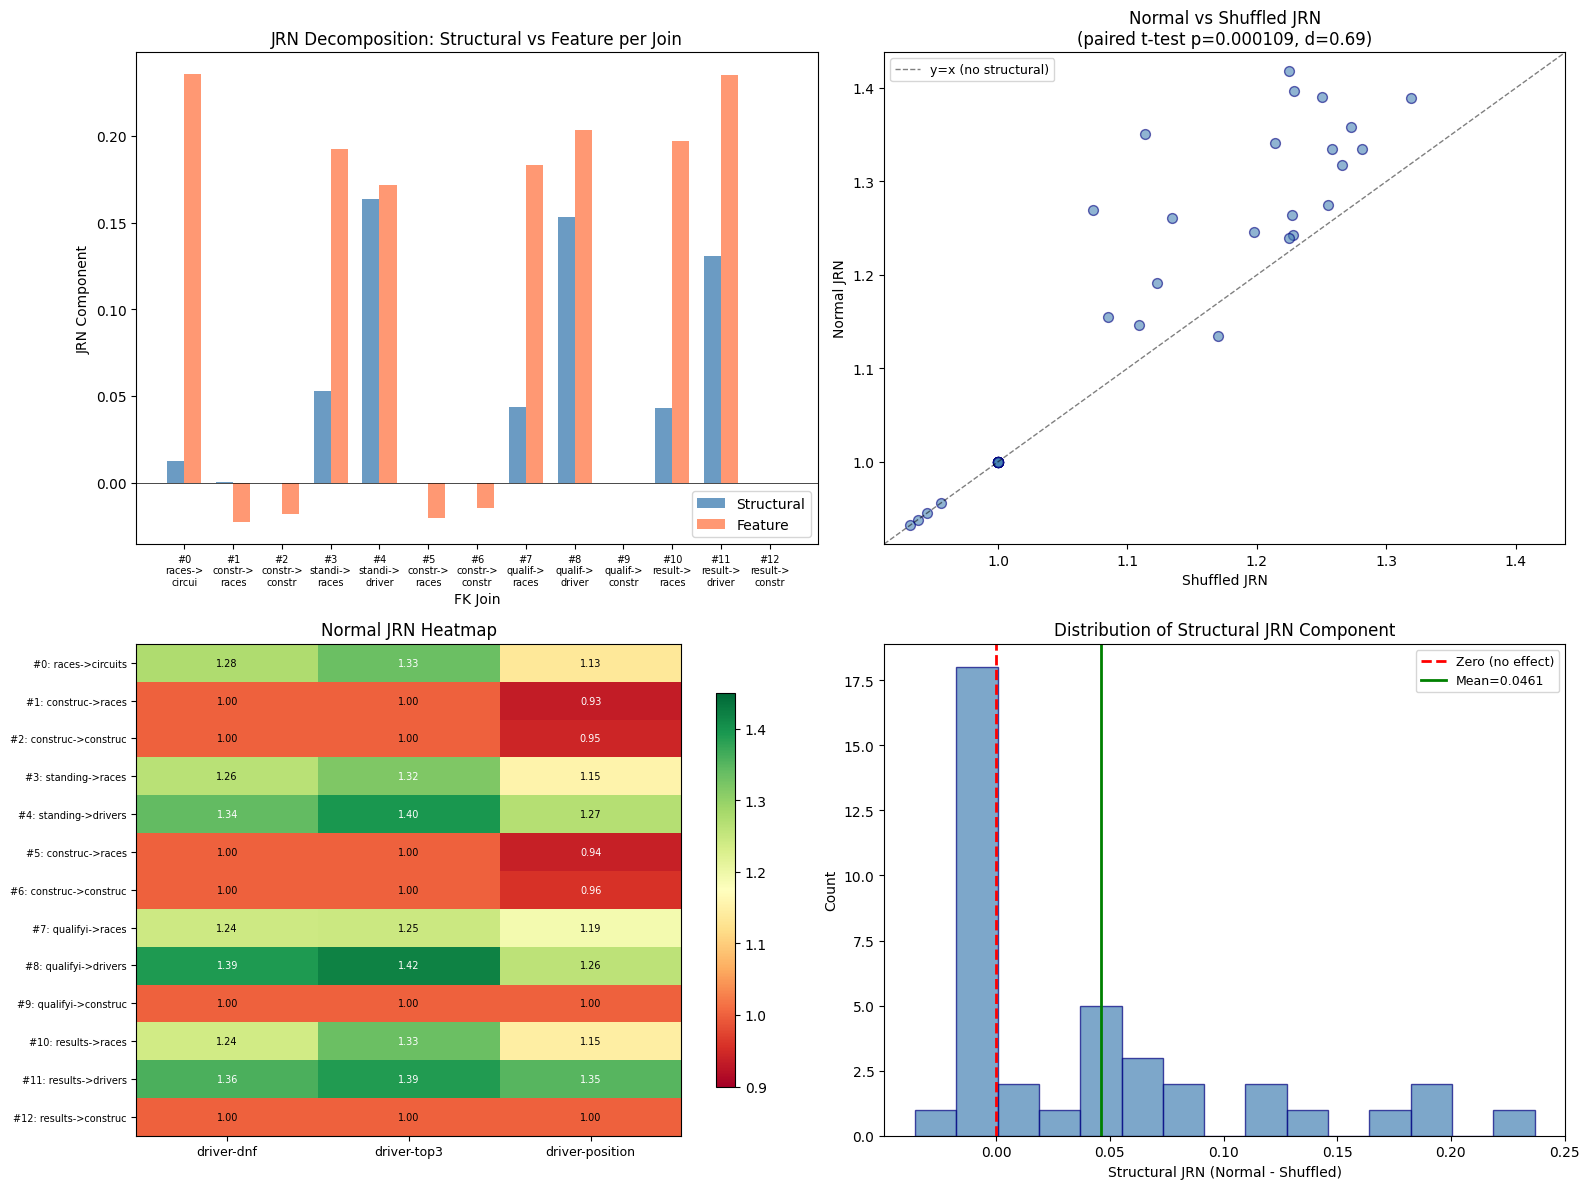

Figure saved to jrn_fk_shuffling_results.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Plot 1: Stacked bar chart of structural vs feature JRN per join ──
ax = axes[0, 0]
join_indices = [pjr["join_idx"] for pjr in per_join_results]
struct_vals = [pjr.get("avg_structural", 0) or 0 for pjr in per_join_results]
feat_vals = [pjr.get("avg_feature", 0) or 0 for pjr in per_join_results]
short_labels = [f"#{pjr['join_idx']}\n{pjr['source_table'][:6]}->\n{pjr['target_table'][:6]}" 
                for pjr in per_join_results]

x = np.arange(len(join_indices))
width = 0.35
ax.bar(x - width/2, struct_vals, width, label='Structural', color='steelblue', alpha=0.8)
ax.bar(x + width/2, feat_vals, width, label='Feature', color='coral', alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-')
ax.set_xlabel('FK Join')
ax.set_ylabel('JRN Component')
ax.set_title('JRN Decomposition: Structural vs Feature per Join')
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=7, rotation=0)
ax.legend()

# ── Plot 2: Normal vs Shuffled JRN scatter ──
ax = axes[0, 1]
ax.scatter(shuffled_arr, normal_arr, c='steelblue', alpha=0.6, s=50, edgecolors='navy')
lims = [min(min(shuffled_arr), min(normal_arr)) - 0.02, 
        max(max(shuffled_arr), max(normal_arr)) + 0.02]
ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='y=x (no structural)')
ax.set_xlabel('Shuffled JRN')
ax.set_ylabel('Normal JRN')
ax.set_title(f'Normal vs Shuffled JRN\n(paired t-test p={p_ttest:.6f}, d={cohens_d:.2f})')
ax.legend(fontsize=9)
ax.set_xlim(lims)
ax.set_ylim(lims)

# ── Plot 3: JRN heatmap (Normal) ──
ax = axes[1, 0]
jrn_matrix = np.array(results["jrn_matrix_normal"])
task_labels = ["driver-dnf", "driver-top3", "driver-position"]
im = ax.imshow(jrn_matrix, cmap='RdYlGn', aspect='auto', vmin=0.9, vmax=1.45)
ax.set_xticks(range(len(task_labels)))
ax.set_xticklabels(task_labels, fontsize=9)
ax.set_yticks(range(len(per_join_results)))
ax.set_yticklabels([f"#{pjr['join_idx']}: {pjr['source_table'][:8]}->{pjr['target_table'][:8]}" 
                     for pjr in per_join_results], fontsize=7)
ax.set_title('Normal JRN Heatmap')
plt.colorbar(im, ax=ax, shrink=0.8)
for i in range(jrn_matrix.shape[0]):
    for j in range(jrn_matrix.shape[1]):
        v = jrn_matrix[i, j]
        if v is not None:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                   color='black' if 1.0 <= v <= 1.3 else 'white')

# ── Plot 4: Distribution of structural JRN differences ──
ax = axes[1, 1]
diffs = normal_arr - shuffled_arr
ax.hist(diffs, bins=15, color='steelblue', alpha=0.7, edgecolor='navy')
ax.axvline(x=0, color='red', linewidth=2, linestyle='--', label='Zero (no effect)')
ax.axvline(x=np.mean(diffs), color='green', linewidth=2, linestyle='-', 
           label=f'Mean={np.mean(diffs):.4f}')
ax.set_xlabel('Structural JRN (Normal - Shuffled)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Structural JRN Component')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('jrn_fk_shuffling_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure saved to jrn_fk_shuffling_results.png")